Copyright Matlantis Corp. as contributors to Matlantis contrib project

# アンブレラサンプリングの初期構造の選択

Steered MDで得られたトラジェクトリから、各アンブレラサンプリング・ウィンドウに対応する初期構造を抽出します。

SMDの軌跡（反応座標の時系列データ）の中から、各ウィンドウの目標値に最も近い構造を選び出し、ファイルとして保存します。

## Step 1: ライブラリのインポート

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from ase.io import read, write, Trajectory

## Step 2: SMDトラジェクトリーの読み込み

Steered MDで出力された反応座標のログ (`COLVAR_SMD`) と全トラジェクトリ (`md-dyn.traj`) を読み込みます。

* `cv_traj`: PLUMEDのCOLVARファイルから読み込んだ反応座標（Cu原子のz座標）の時系列。
* `smd_traj`: ASEのTrajectoryオブジェクトとして読み込んだ全スナップショット。
* `rc_range`: アンブレラサンプリングのウィンドウ中心の配列（10.2 Å から 18.0 Å、0.2 Å刻み、40ウィンドウ）。

In [ ]:
# 1. 反応座標（RC）の範囲を指定
rc_range = np.linspace(10.2, 18.0, 40)

# 2. PLUMEDのログファイルを読み込む
cv_traj = np.loadtxt('./output/03_steered_md_moving_restrain/COLVAR_SMD')[:, 1]

# 3. SMDの全トラジェクトリを一度読み込む
smd_traj = Trajectory('./output/03_steered_md_moving_restrain/md-dyn.traj') 

cv_traj

## Step 3: 各ウィンドウの初期構造の抽出

各アンブレラサンプリング・ウィンドウの目標反応座標値に最も近いスナップショットをSMDトラジェクトリから選択し、`inputs/` ディレクトリにextxyz形式で保存します。

In [3]:
os.makedirs('inputs', exist_ok=True)

print(f"{'Window':>6}  {'Target RC':>10}  {'Found Index':>12}  {'Actual RC':>10}")
print("-" * 45)

# 4. 各アンブレラ中心に対して、SMDの全ステップから最も近い構造を探索
for i, rc_target in enumerate(rc_range):
    # SMDの全軌跡(cv_traj)の中から、rc_targetに最も近い値のインデックスを探す
    diff = np.abs(cv_traj - rc_target)
    jmin = np.argmin(diff)


    # 確認用プリント
    actual_cv = cv_traj[int(jmin)]
    print(f"{i:6d}  {rc_target:10.2f}  {jmin:12d}  {actual_cv:10.4f}")
    
    # 構造を取得
    atoms = smd_traj[int(jmin)] 
    
    # 保存
    filename_base = f'./inputs/initial_rc_{rc_target:.2f}'
    write(f'{filename_base}.xyz', atoms, format='extxyz')

Window   Target RC   Found Index   Actual RC
---------------------------------------------
     0       10.20             0     10.1949
     1       10.30            33     10.2980
     2       10.40            71     10.3976
     3       10.50            98     10.5004
     4       10.60           119     10.6021
     5       10.70           130     10.7009
     6       10.80           169     10.7995
     7       10.90           199     10.9003
     8       11.00           239     11.0004
     9       11.10           260     11.1013
    10       11.20           297     11.2000
    11       11.30           303     11.2988
    12       11.40           312     11.4002
    13       11.50           337     11.4998
    14       11.60           390     11.6004
    15       11.70           433     11.7058
    16       11.80           420     11.7990
    17       11.90           449     11.9005
    18       12.00           488     11.9999
    19       12.10           545     12.1019
    20   

## Step 4: 結果の確認

SMDトラジェクトリにおける反応座標の推移をプロットし、引き離しが正しく行われたことを確認します。

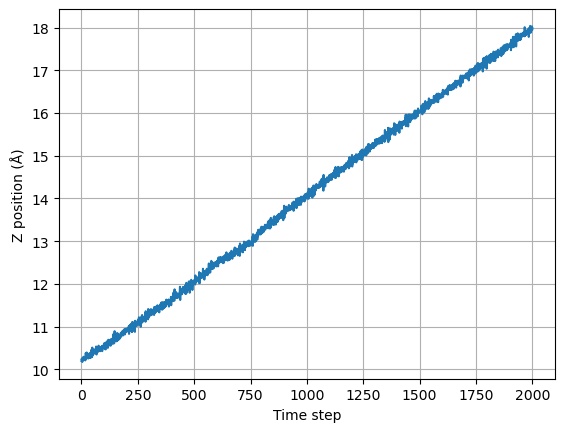

In [4]:
plt.plot(cv_traj)
plt.grid()
plt.xlabel('Time step')
plt.ylabel('Z position (Å)')
plt.show()

## Next Step
これで、アンブレラサンプリング用の初期構造の準備が完了しました。40個の初期構造が `inputs/` ディレクトリに保存されています。
次の [05_umbrella_sampling_ja.ipynb](./05_umbrella_sampling_ja.ipynb) では、これらの初期構造を使って、各ウィンドウでのアンブレラサンプリングMDを実行します。